# Autoencoder con feature jet-level + track-level

Questo notebook costruisce una pipeline completa e semplice:

1. legge i file `.h5` originali;
2. seleziona feature jet-level e track-level;
3. normalizza usando `norm_dict.yaml`;
4. salva dataset preprocessati `.npz`;
5. allena un autoencoder su background/validation;
6. calcola anomaly score su background e signal;
7. produce ROC e AUC.

Qui il modello usa sia:

```text
X_jets      = feature globali del jet
X_tracks    = feature delle tracce
track_mask  = maschera delle tracce valide
```

## 1. Import

In [16]:
from pathlib import Path
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve

## 2. Controllo GPU

In [17]:
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 3. Path dei file

In [18]:
RAW_DIR = Path(".")
PROCESSED_DIR = Path("processed")
OUTPUT_DIR = Path("outputs")

PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

raw_files = {
    "val": RAW_DIR / "pp_output_val.h5",
    "test_background": RAW_DIR / "pp_output_test_background.h5",
    "test_signal": RAW_DIR / "pp_output_test_signal.h5",
}

norm_path = RAW_DIR / "norm_dict.yaml"

for name, path in raw_files.items():
    print(name, "->", path, "exists:", path.exists())

print("norm_dict:", norm_path, "exists:", norm_path.exists())

val -> pp_output_val.h5 exists: True
test_background -> pp_output_test_background.h5 exists: True
test_signal -> pp_output_test_signal.h5 exists: True
norm_dict: norm_dict.yaml exists: True


## 4. Caricamento norm_dict

In [19]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

norm_dict = load_yaml(norm_path)

print("Numero jet features in norm_dict:", len(norm_dict["jets"]))
print("Numero track features in norm_dict:", len(norm_dict["tracks"]))

Numero jet features in norm_dict: 15
Numero track features in norm_dict: 26


## 5. Feature scelte

In [20]:
# Non usare come input:
# isDisplaced, flavour_label, salt_pdisp, isTagged, eventNumber,
# truthOriginLabel, truthVertexIndex, VSIVertexIndex.

jet_features = [
    "pt",
    "eta",
    "mass",
    "energy",
    "displacedPtFraction",
    "Qw_clusterSoftDrop",
    "C2_clusterSoftDrop",
    "D2_clusterSoftDrop",
    "Tau1_clusterSoftDrop",
    "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop",
    "Tau21_clusterSoftDrop",
    "Tau32_clusterSoftDrop",
    "ECF1_clusterSoftDrop",
    "ECF2_clusterSoftDrop",
]

track_features = [
    "d0",
    "z0SinTheta",
    "dphi",
    "deta",
    "pt_log1p",
    "radiusOfFirstHit",
    "numberOfPixelHits",
    "numberOfSCTHits",
    "numberOfSCTHoles",
    "numberOfInnermostPixelLayerHits",
    "numberOfPixelSharedHits",
    "numberOfSCTSharedHits",
]

print("Jet features:", jet_features)
print("Track features:", track_features)
print("n jet features:", len(jet_features))
print("n track features:", len(track_features))

Jet features: ['pt', 'eta', 'mass', 'energy', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
Track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
n jet features: 15
n track features: 12


## 6. Controllo feature disponibili

In [21]:
def get_fields(file_path, dataset_name):
    with h5py.File(file_path, "r") as f:
        return set(f[dataset_name].dtype.names)

jet_fields = {name: get_fields(path, "jets") for name, path in raw_files.items()}
track_fields = {name: get_fields(path, "tracks") for name, path in raw_files.items()}

for name in raw_files:
    missing_jets = set(jet_features) - jet_fields[name]
    missing_tracks = set(track_features) - track_fields[name]

    print("", name)
    print("missing jet features:", missing_jets)
    print("missing track features:", missing_tracks)

    if missing_jets or missing_tracks:
        raise ValueError(f"Feature mancanti nel file {name}. Modifica jet_features o track_features.")

 val
missing jet features: set()
missing track features: set()
 test_background
missing jet features: set()
missing track features: set()
 test_signal
missing jet features: set()
missing track features: set()


## 7. Funzioni di preprocessing

In [22]:
def get_norm_stats(norm_dict, object_type, feature):
    if object_type not in norm_dict:
        return None
    if feature not in norm_dict[object_type]:
        return None
    mean = float(norm_dict[object_type][feature]["mean"])
    std = float(norm_dict[object_type][feature]["std"])
    std = max(std, 1e-8)
    return mean, std


def build_jet_track_dataset(file_path, jet_features, track_features, norm_dict, max_jets=None, verbose=True):
    file_path = Path(file_path)

    if verbose:
        print("\n" + "=" * 100)
        print("Processing:", file_path)
        print("=" * 100)

    with h5py.File(file_path, "r") as f:
        jets = f["jets"]
        tracks = f["tracks"]

        n_total = jets.shape[0]
        n = n_total if max_jets is None else min(max_jets, n_total)
        n_tracks = tracks.shape[1]

        if verbose:
            print("Total jets:", n_total)
            print("Jets used:", n)
            print("Tracks per jet:", n_tracks)

        X_jets = np.empty((n, len(jet_features)), dtype=np.float32)
        jet_norm_stats = {}

        for i, feat in enumerate(jet_features):
            if feat not in jets.dtype.names:
                raise KeyError(f"Jet feature {feat} non trovata in {file_path}")
            x = np.asarray(jets[feat][:n], dtype=np.float32)
            stats = get_norm_stats(norm_dict, "jets", feat)
            if stats is None:
                mean = float(np.nanmean(x))
                std = float(np.nanstd(x))
                std = max(std, 1e-8)
                if verbose:
                    print(f"WARNING: {feat} non in norm_dict['jets']; uso stats calcolate.")
            else:
                mean, std = stats
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            X_jets[:, i] = x
            jet_norm_stats[feat] = {"mean": mean, "std": std}

        track_mask = np.asarray(tracks["valid"][:n], dtype=bool)
        X_tracks = np.empty((n, n_tracks, len(track_features)), dtype=np.float32)
        track_norm_stats = {}

        for i, feat in enumerate(track_features):
            if feat not in tracks.dtype.names:
                raise KeyError(f"Track feature {feat} non trovata in {file_path}")
            x = np.asarray(tracks[feat][:n], dtype=np.float32)
            stats = get_norm_stats(norm_dict, "tracks", feat)
            if stats is None:
                valid_values = x[track_mask]
                mean = float(np.nanmean(valid_values))
                std = float(np.nanstd(valid_values))
                std = max(std, 1e-8)
                if verbose:
                    print(f"WARNING: {feat} non in norm_dict['tracks']; uso stats calcolate.")
            else:
                mean, std = stats
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            x[~track_mask] = 0.0
            X_tracks[:, :, i] = x
            track_norm_stats[feat] = {"mean": mean, "std": std}

        metadata = {}
        for key in ["isDisplaced", "flavour_label", "mcEventWeight", "eventNumber"]:
            if key in jets.dtype.names:
                metadata[key] = np.asarray(jets[key][:n])

        filename = file_path.name.lower()
        if "background" in filename:
            y = np.zeros(n, dtype=np.int64)
        elif "signal" in filename:
            y = np.ones(n, dtype=np.int64)
        elif "isDisplaced" in metadata:
            y = metadata["isDisplaced"].astype(np.int64)
        else:
            y = None

    if verbose:
        print("X_jets:", X_jets.shape, X_jets.dtype)
        print("X_tracks:", X_tracks.shape, X_tracks.dtype)
        print("track_mask:", track_mask.shape, track_mask.dtype)
        print("finite X_jets:", np.isfinite(X_jets).all())
        print("finite X_tracks:", np.isfinite(X_tracks).all())
        print("invalid tracks zero:", np.allclose(X_tracks[~track_mask], 0.0))
        if y is not None:
            print("y:", np.unique(y, return_counts=True))

    norm_stats = {"jets": jet_norm_stats, "tracks": track_norm_stats}
    return X_jets, X_tracks, track_mask, metadata, y, norm_stats

## 8. Funzioni di salvataggio e controllo

In [23]:
def save_processed_dataset(out_path, X_jets, X_tracks, track_mask, jet_features, track_features, metadata=None, y=None, norm_stats=None):
    out_path = Path(out_path)
    payload = {
        "X_jets": X_jets.astype(np.float32),
        "X_tracks": X_tracks.astype(np.float32),
        "track_mask": track_mask.astype(bool),
        "jet_feature_names": np.array(jet_features, dtype=object),
        "track_feature_names": np.array(track_features, dtype=object),
    }
    if y is not None:
        payload["y"] = y.astype(np.int64)
    if metadata is not None:
        for key, value in metadata.items():
            payload[f"meta_{key}"] = value
    if norm_stats is not None:
        for feat in jet_features:
            payload[f"norm_jets_mean_{feat}"] = np.array(norm_stats["jets"][feat]["mean"], dtype=np.float32)
            payload[f"norm_jets_std_{feat}"] = np.array(norm_stats["jets"][feat]["std"], dtype=np.float32)
        for feat in track_features:
            payload[f"norm_tracks_mean_{feat}"] = np.array(norm_stats["tracks"][feat]["mean"], dtype=np.float32)
            payload[f"norm_tracks_std_{feat}"] = np.array(norm_stats["tracks"][feat]["std"], dtype=np.float32)
    print("Saving:", out_path)
    np.savez_compressed(out_path, **payload)
    print("Saved.")


def check_processed_dataset(path):
    path = Path(path)
    data = np.load(path, allow_pickle=True)
    print("\n" + "=" * 100)
    print("Checking:", path)
    print("=" * 100)
    print("keys:", list(data.keys()))
    X_jets = data["X_jets"]
    X_tracks = data["X_tracks"]
    mask = data["track_mask"]
    print("X_jets:", X_jets.shape, X_jets.dtype)
    print("X_tracks:", X_tracks.shape, X_tracks.dtype)
    print("track_mask:", mask.shape, mask.dtype)
    print("jet features:", list(data["jet_feature_names"]))
    print("track features:", list(data["track_feature_names"]))
    print("finite X_jets:", np.isfinite(X_jets).all())
    print("finite X_tracks:", np.isfinite(X_tracks).all())
    print("invalid tracks zero:", np.allclose(X_tracks[~mask], 0.0))
    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))
    return data

## 9. Costruzione dataset preprocessati

In [24]:
processed_files = {
    "val": PROCESSED_DIR / "processed_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_jet_track_test_signal.npz",
}

# Per debug puoi mettere numeri piccoli.
# Per usare tutto: None.
max_jets_map = {
    "val": 100_000,
    "test_background": 100_000,
    "test_signal": None,
}

for split_name, file_path in raw_files.items():
    print("" + "#" * 100)
    print("BUILDING DATASET:", split_name)
    print("#" * 100)

    X_jets, X_tracks, track_mask, metadata, y, norm_stats = build_jet_track_dataset(
        file_path=file_path,
        jet_features=jet_features,
        track_features=track_features,
        norm_dict=norm_dict,
        max_jets=max_jets_map[split_name],
        verbose=True,
    )

    save_processed_dataset(
        out_path=processed_files[split_name],
        X_jets=X_jets,
        X_tracks=X_tracks,
        track_mask=track_mask,
        jet_features=jet_features,
        track_features=track_features,
        metadata=metadata,
        y=y,
        norm_stats=norm_stats,
    )

    check_processed_dataset(processed_files[split_name])

####################################################################################################
BUILDING DATASET: val
####################################################################################################

Processing: pp_output_val.h5
Total jets: 1000000
Jets used: 100000
Tracks per jet: 200
X_jets: (100000, 15) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
finite X_jets: True
finite X_tracks: True
invalid tracks zero: True
y: (array([0]), array([100000]))
Saving: processed\processed_jet_track_val.npz
Saved.

Checking: processed\processed_jet_track_val.npz
keys: ['X_jets', 'X_tracks', 'track_mask', 'jet_feature_names', 'track_feature_names', 'y', 'meta_isDisplaced', 'meta_flavour_label', 'norm_jets_mean_pt', 'norm_jets_std_pt', 'norm_jets_mean_eta', 'norm_jets_std_eta', 'norm_jets_mean_mass', 'norm_jets_std_mass', 'norm_jets_mean_energy', 'norm_jets_std_energy', 'norm_jets_mean_displacedPtFraction', 'norm_jets_std_displacedPtFraction', 'n

## 10. Caricamento dataset preprocessati

In [25]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_all = data_train["X_jets"].astype(np.float32)
X_tracks_all = data_train["X_tracks"].astype(np.float32)
mask_all = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

n_jet_features = X_jets_all.shape[1]
n_tracks = X_tracks_all.shape[1]
n_track_features = X_tracks_all.shape[2]

print("X_jets_all:", X_jets_all.shape)
print("X_tracks_all:", X_tracks_all.shape)
print("mask_all:", mask_all.shape)
print("n_jet_features:", n_jet_features)
print("n_tracks:", n_tracks)
print("n_track_features:", n_track_features)
print("jet features:", jet_feature_names)
print("track features:", track_feature_names)

X_jets_all: (100000, 15)
X_tracks_all: (100000, 200, 12)
mask_all: (100000, 200)
n_jet_features: 15
n_tracks: 200
n_track_features: 12
jet features: ['pt', 'eta', 'mass', 'energy', 'displacedPtFraction', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']


## 11. Visualizzazioni rapide

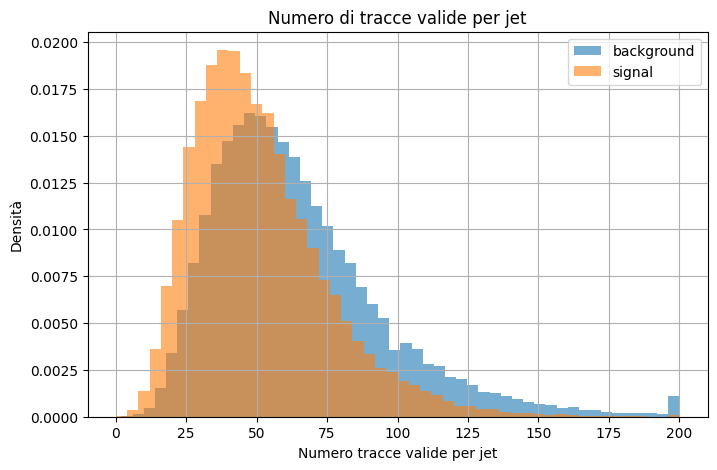

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(mask_bg.sum(axis=1), bins=50, density=True, alpha=0.6, label="background")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.6, label="signal")
plt.xlabel("Numero tracce valide per jet")
plt.ylabel("Densità")
plt.title("Numero di tracce valide per jet")
plt.legend()
plt.grid(True)
plt.show()

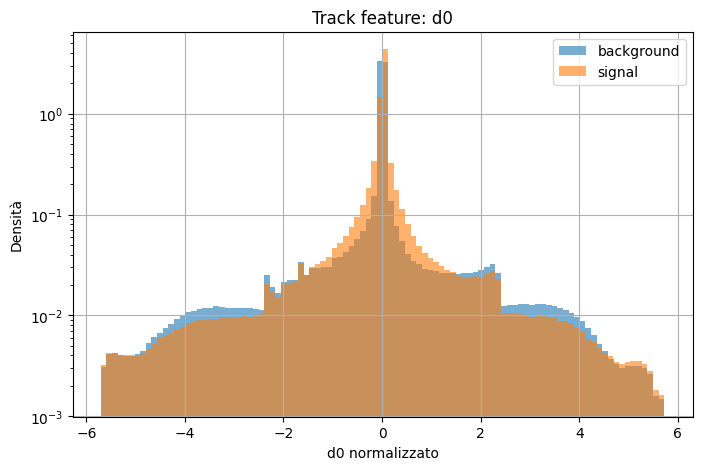

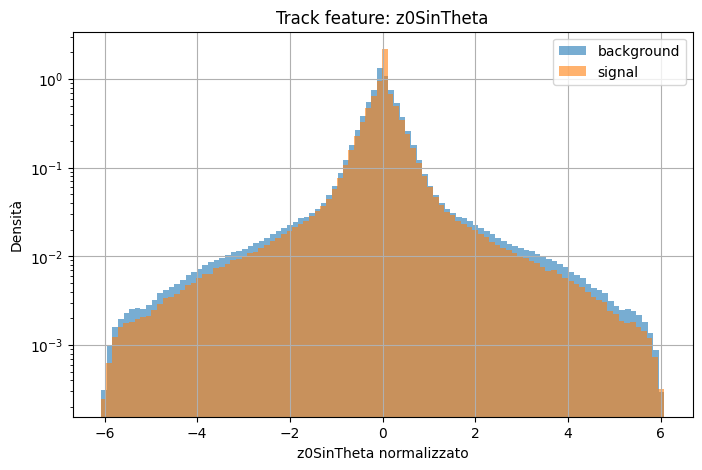

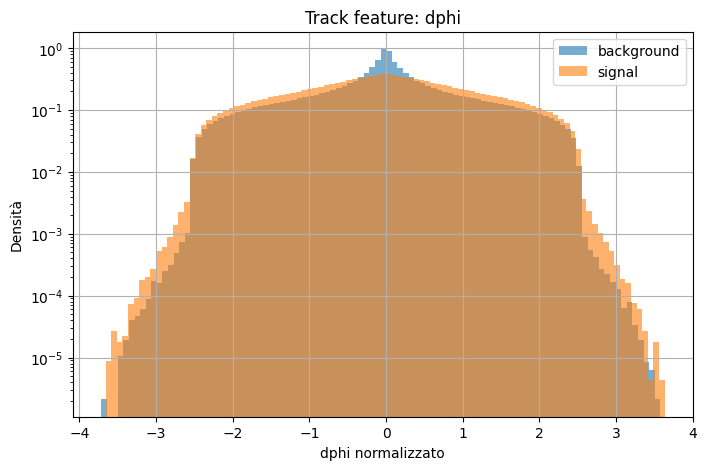

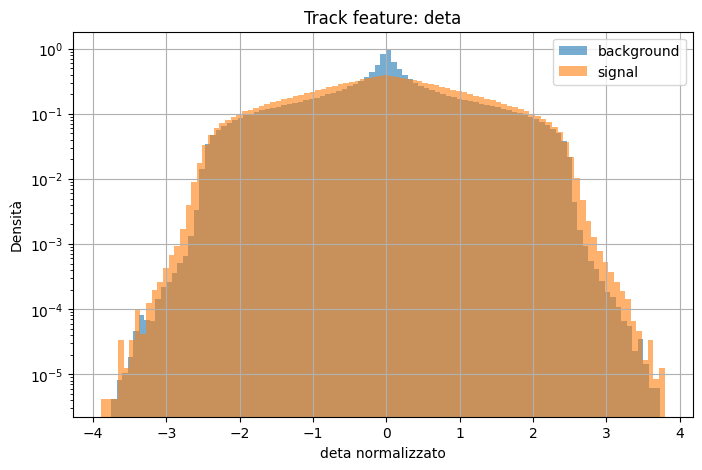

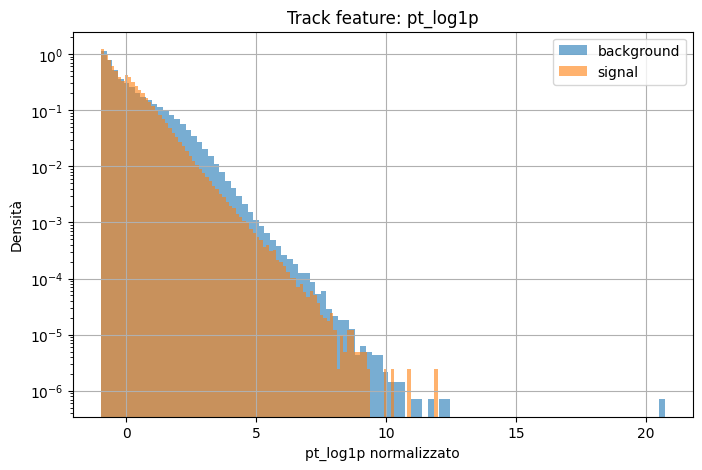

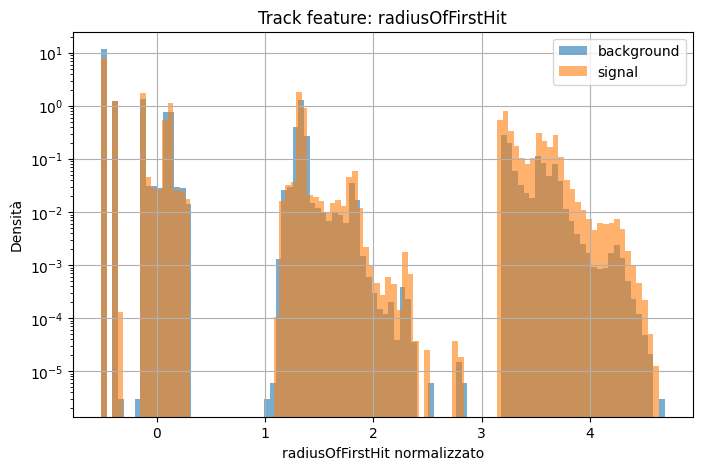

In [27]:
def plot_track_feature(i):
    feat = track_feature_names[i]
    bg_vals = X_tracks_bg[:, :, i][mask_bg]
    sig_vals = X_tracks_sig[:, :, i][mask_sig]
    plt.figure(figsize=(8, 5))
    plt.hist(bg_vals, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_vals, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel(f"{feat} normalizzato")
    plt.ylabel("Densità")
    plt.title(f"Track feature: {feat}")
    plt.legend()
    plt.grid(True)
    plt.show()

for i in range(min(len(track_feature_names), 6)):
    plot_track_feature(i)

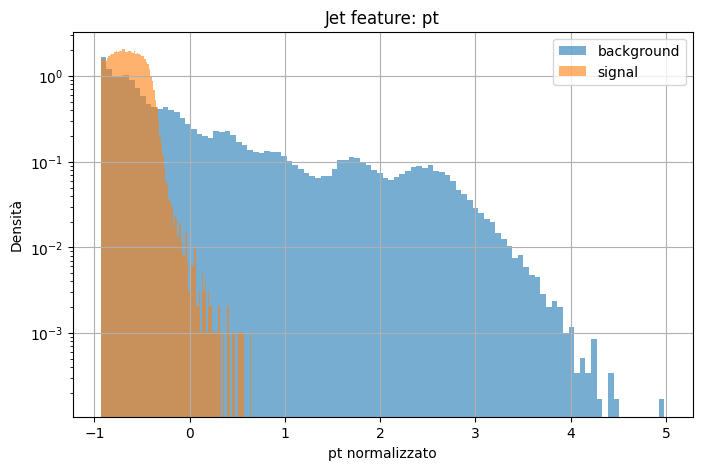

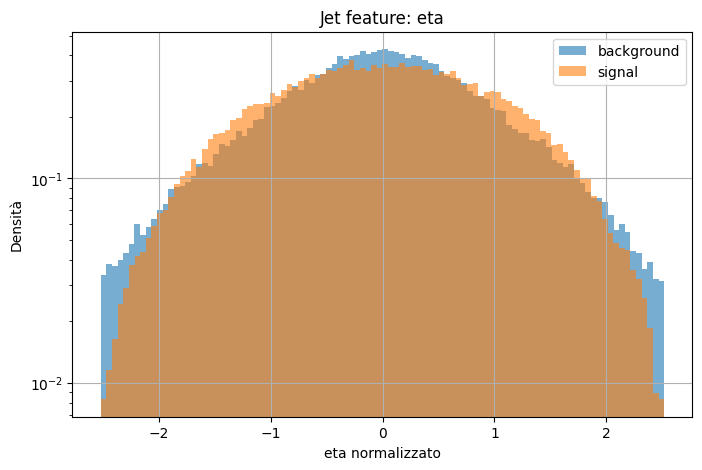

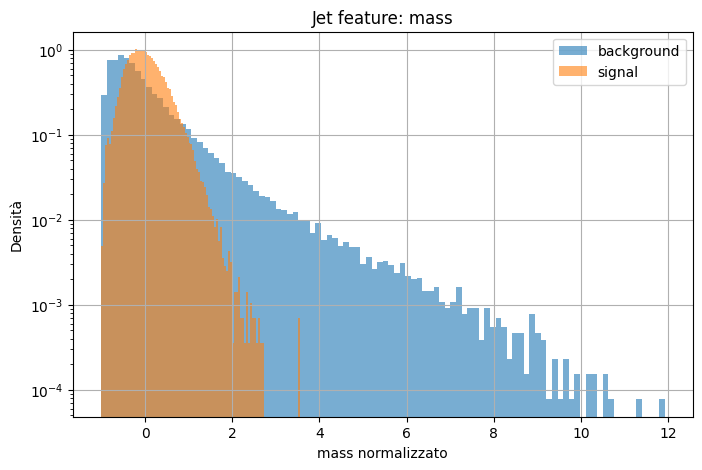

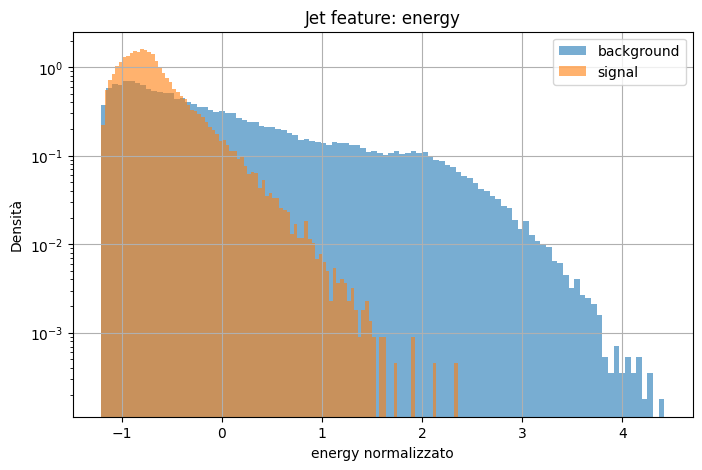

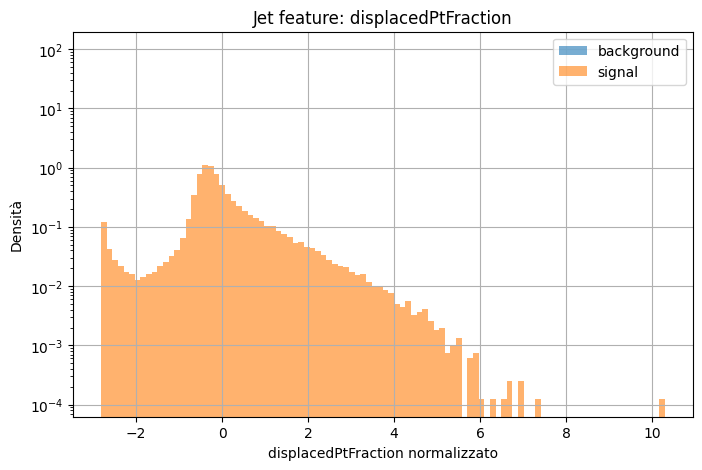

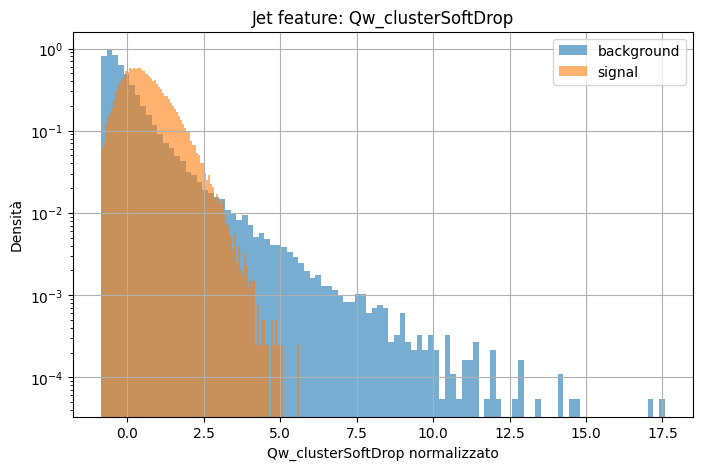

In [28]:
def plot_jet_feature(i):
    feat = jet_feature_names[i]
    bg_vals = X_jets_bg[:, i]
    sig_vals = X_jets_sig[:, i]
    plt.figure(figsize=(8, 5))
    plt.hist(bg_vals, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_vals, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel(f"{feat} normalizzato")
    plt.ylabel("Densità")
    plt.title(f"Jet feature: {feat}")
    plt.legend()
    plt.grid(True)
    plt.show()

for i in range(min(len(jet_feature_names), 6)):
    plot_jet_feature(i)

## 12. Dataset PyTorch

In [29]:
class JetTrackDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]

## 13. Train/validation split

In [30]:
full_dataset = JetTrackDataset(X_jets_all, X_tracks_all, mask_all)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train jets:", len(train_dataset))
print("Validation jets:", len(val_dataset))

Train jets: 80000
Validation jets: 20000


## 14. Autoencoder combinato jet + tracks

In [31]:
class JetTrackAutoencoder(nn.Module):
    def __init__(self, n_jet_features, n_tracks, n_track_features, latent_dim=64):
        super().__init__()
        self.n_jet_features = n_jet_features
        self.n_tracks = n_tracks
        self.n_track_features = n_track_features
        track_input_dim = n_tracks * n_track_features
        jet_input_dim = n_jet_features
        total_input_dim = track_input_dim + jet_input_dim
        self.encoder = nn.Sequential(
            nn.Linear(total_input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, total_input_dim),
        )

    def forward(self, x_jets, x_tracks):
        batch_size = x_jets.shape[0]
        x_tracks_flat = x_tracks.reshape(batch_size, -1)
        x = torch.cat([x_jets, x_tracks_flat], dim=1)
        z = self.encoder(x)
        out = self.decoder(z)
        jet_dim = self.n_jet_features
        track_dim = self.n_tracks * self.n_track_features
        reco_jets = out[:, :jet_dim]
        reco_tracks = out[:, jet_dim:jet_dim + track_dim]
        reco_tracks = reco_tracks.reshape(batch_size, self.n_tracks, self.n_track_features)
        return reco_jets, reco_tracks

## 15. Loss combinata

In [32]:
def masked_track_mse_loss(reco_tracks, x_tracks, mask):
    mask_expanded = mask.unsqueeze(-1)
    diff2 = (reco_tracks - x_tracks) ** 2
    diff2 = diff2 * mask_expanded
    denom = mask_expanded.sum() * x_tracks.shape[-1]
    denom = torch.clamp(denom, min=1)
    return diff2.sum() / denom


def jet_mse_loss(reco_jets, x_jets):
    return torch.mean((reco_jets - x_jets) ** 2)


def combined_loss(reco_jets, reco_tracks, x_jets, x_tracks, mask, jet_weight=1.0, track_weight=1.0):
    loss_tracks = masked_track_mse_loss(reco_tracks, x_tracks, mask)
    loss_jets = jet_mse_loss(reco_jets, x_jets)
    loss = track_weight * loss_tracks + jet_weight * loss_jets
    return loss, loss_jets, loss_tracks

## 16. Creazione modello

In [33]:
latent_dim = 64
jet_weight = 1.0
track_weight = 1.0

model = JetTrackAutoencoder(
    n_jet_features=n_jet_features,
    n_tracks=n_tracks,
    n_track_features=n_track_features,
    latent_dim=latent_dim,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

print(model)

JetTrackAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2415, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, 

## 17. Valutazione loss

In [34]:
def evaluate_loss(model, loader, jet_weight=1.0, track_weight=1.0):
    model.eval()
    total_loss = 0.0
    total_jet_loss = 0.0
    total_track_loss = 0.0
    total_items = 0
    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            reco_jets, reco_tracks = model(x_jets, x_tracks)
            loss, loss_jets, loss_tracks = combined_loss(
                reco_jets, reco_tracks, x_jets, x_tracks, mask,
                jet_weight=jet_weight, track_weight=track_weight,
            )
            b = x_jets.shape[0]
            total_loss += loss.item() * b
            total_jet_loss += loss_jets.item() * b
            total_track_loss += loss_tracks.item() * b
            total_items += b
    return total_loss / total_items, total_jet_loss / total_items, total_track_loss / total_items

## 18. Training

In [35]:
n_epochs = 1000
train_losses = []
val_losses = []
train_jet_losses = []
train_track_losses = []
val_jet_losses = []
val_track_losses = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0
    total_jet_loss = 0.0
    total_track_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        optimizer.zero_grad()
        reco_jets, reco_tracks = model(x_jets, x_tracks)
        loss, loss_jets, loss_tracks = combined_loss(
            reco_jets, reco_tracks, x_jets, x_tracks, mask,
            jet_weight=jet_weight, track_weight=track_weight,
        )
        loss.backward()
        optimizer.step()
        b = x_jets.shape[0]
        total_loss += loss.item() * b
        total_jet_loss += loss_jets.item() * b
        total_track_loss += loss_tracks.item() * b
        total_items += b

    avg_train_loss = total_loss / total_items
    avg_train_jet_loss = total_jet_loss / total_items
    avg_train_track_loss = total_track_loss / total_items
    avg_val_loss, avg_val_jet_loss, avg_val_track_loss = evaluate_loss(
        model, val_loader, jet_weight=jet_weight, track_weight=track_weight
    )

    train_losses.append(avg_train_loss)
    train_jet_losses.append(avg_train_jet_loss)
    train_track_losses.append(avg_train_track_loss)
    val_losses.append(avg_val_loss)
    val_jet_losses.append(avg_val_jet_loss)
    val_track_losses.append(avg_val_track_loss)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"train={avg_train_loss:.6f} "
        f"(jet={avg_train_jet_loss:.6f}, track={avg_train_track_loss:.6f}) | "
        f"val={avg_val_loss:.6f} "
        f"(jet={avg_val_jet_loss:.6f}, track={avg_val_track_loss:.6f})"
    )

Epoch 01/1000 | train=1.026661 (jet=0.136390, track=0.890271) | val=0.907595 (jet=0.049684, track=0.857911)
Epoch 02/1000 | train=0.888224 (jet=0.045183, track=0.843041) | val=0.890986 (jet=0.054838, track=0.836149)
Epoch 03/1000 | train=0.845526 (jet=0.031753, track=0.813773) | val=0.834149 (jet=0.029779, track=0.804371)
Epoch 04/1000 | train=0.808453 (jet=0.026334, track=0.782119) | val=0.809847 (jet=0.030285, track=0.779562)
Epoch 05/1000 | train=0.778043 (jet=0.022433, track=0.755609) | val=0.799144 (jet=0.040899, track=0.758244)
Epoch 06/1000 | train=0.755962 (jet=0.021610, track=0.734352) | val=0.774948 (jet=0.033907, track=0.741041)
Epoch 07/1000 | train=0.735913 (jet=0.019205, track=0.716708) | val=0.754257 (jet=0.028197, track=0.726059)
Epoch 08/1000 | train=0.724101 (jet=0.020297, track=0.703805) | val=0.749668 (jet=0.028934, track=0.720733)
Epoch 09/1000 | train=0.710874 (jet=0.018838, track=0.692036) | val=0.750158 (jet=0.040652, track=0.709506)
Epoch 10/1000 | train=0.7002

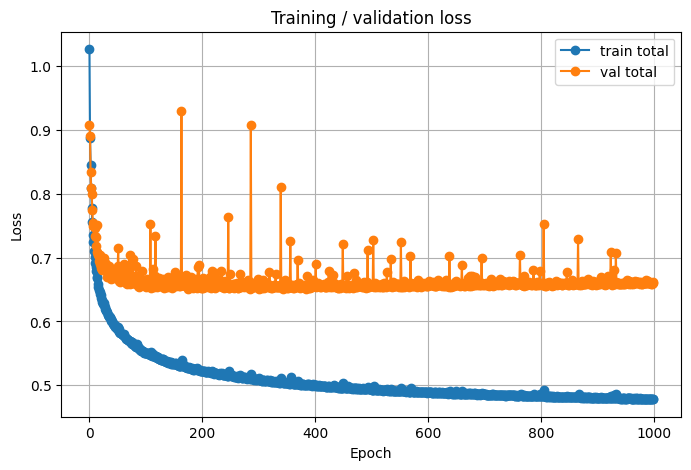

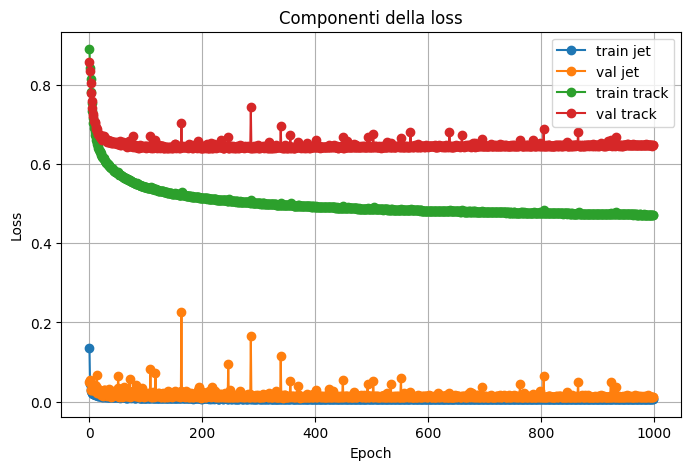

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="train total")
plt.plot(val_losses, marker="o", label="val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_jet_losses, marker="o", label="train jet")
plt.plot(val_jet_losses, marker="o", label="val jet")
plt.plot(train_track_losses, marker="o", label="train track")
plt.plot(val_track_losses, marker="o", label="val track")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Componenti della loss")
plt.legend()
plt.grid(True)
plt.show()

## 19. Anomaly score

In [37]:
class JetTrackEvalDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()
    def __len__(self):
        return self.X_jets.shape[0]
    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


def compute_anomaly_scores(model, X_jets, X_tracks, mask, batch_size=2048, jet_weight=1.0, track_weight=1.0):
    dataset = JetTrackEvalDataset(X_jets, X_tracks, mask)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    model.eval()
    scores_total = []
    scores_jets = []
    scores_tracks = []
    with torch.no_grad():
        for x_jets, x_tracks, mask_batch in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            reco_jets, reco_tracks = model(x_jets, x_tracks)
            jet_error = ((reco_jets - x_jets) ** 2).mean(dim=1)
            diff2_tracks = (reco_tracks - x_tracks) ** 2
            diff2_tracks = diff2_tracks * mask_batch.unsqueeze(-1)
            track_error_sum = diff2_tracks.sum(dim=(1, 2))
            track_denom = mask_batch.sum(dim=1) * x_tracks.shape[-1]
            track_denom = torch.clamp(track_denom, min=1)
            track_error = track_error_sum / track_denom
            total_score = jet_weight * jet_error + track_weight * track_error
            scores_total.append(total_score.cpu().numpy())
            scores_jets.append(jet_error.cpu().numpy())
            scores_tracks.append(track_error.cpu().numpy())
    return np.concatenate(scores_total), np.concatenate(scores_jets), np.concatenate(scores_tracks)

## 20. Calcolo score background e signal

In [39]:
scores_bg, scores_bg_jets, scores_bg_tracks = compute_anomaly_scores(
    model, X_jets_bg, X_tracks_bg, mask_bg,
    batch_size=2048, jet_weight=jet_weight, track_weight=track_weight,
)

scores_sig, scores_sig_jets, scores_sig_tracks = compute_anomaly_scores(
    model, X_jets_sig, X_tracks_sig, mask_sig,
    batch_size=2048, jet_weight=jet_weight, track_weight=track_weight,
)

print("Total score")
print("  bg mean:", scores_bg.mean(), "median:", np.median(scores_bg))
print("  sig mean:", scores_sig.mean(), "median:", np.median(scores_sig))

print("Jet score")
print("  bg mean:", scores_bg_jets.mean(), "median:", np.median(scores_bg_jets))
print("  sig mean:", scores_sig_jets.mean(), "median:", np.median(scores_sig_jets))

print("track score")
print("  bg mean:", scores_bg_tracks.mean(), "median:", np.median(scores_bg_tracks))
print("  sig mean:", scores_sig_tracks.mean(), "median:", np.median(scores_sig_tracks))

Total score
  bg mean: 0.54977655 median: 0.49808082
  sig mean: 0.57911295 median: 0.5315157
Jet score
  bg mean: 0.0124219945 median: 0.006199085
  sig mean: 0.08724112 median: 0.033371173
track score
  bg mean: 0.5373546 median: 0.4892969
  sig mean: 0.4918718 median: 0.46296835


## 21. Plot anomaly score

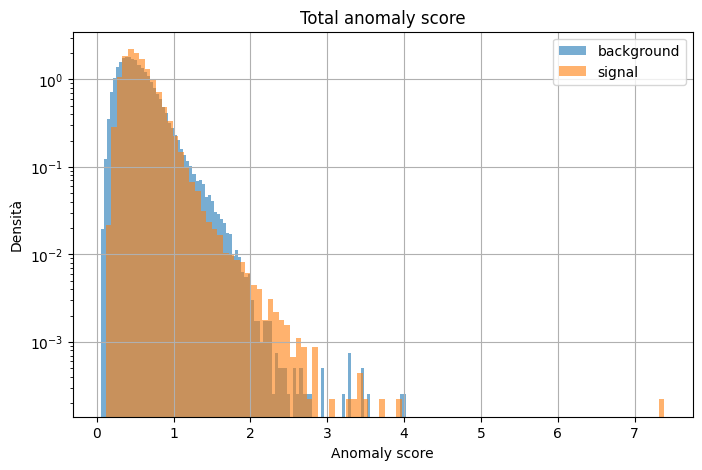

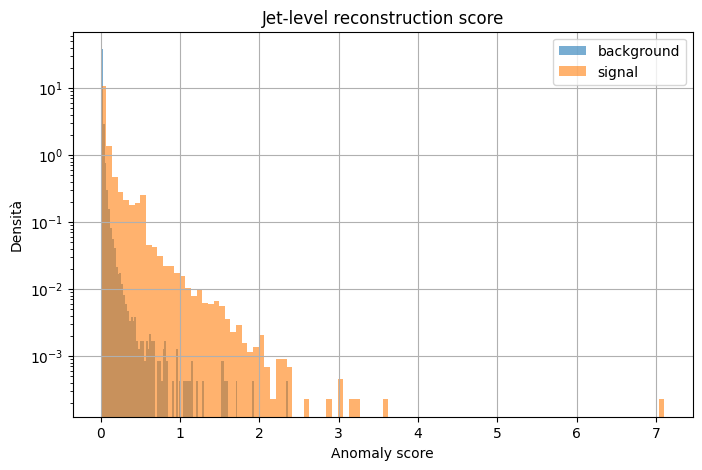

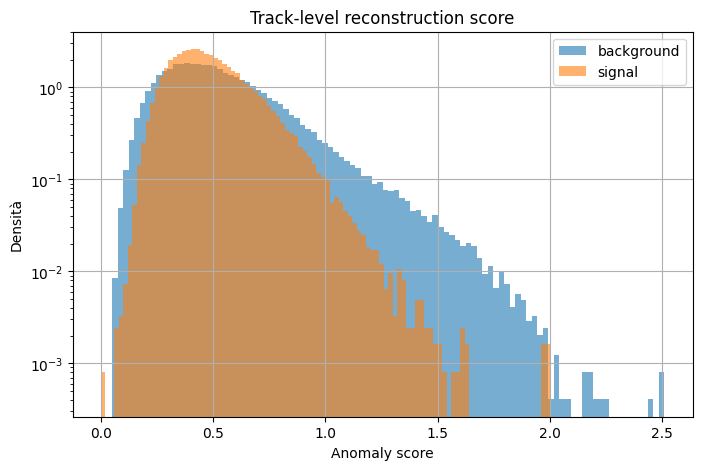

In [40]:
def plot_score_distribution(bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(bg_scores, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("Anomaly score")
    plt.ylabel("Densità")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_score_distribution(scores_bg, scores_sig, "Total anomaly score")
plot_score_distribution(scores_bg_jets, scores_sig_jets, "Jet-level reconstruction score")
plot_score_distribution(scores_bg_tracks, scores_sig_tracks, "Track-level reconstruction score")

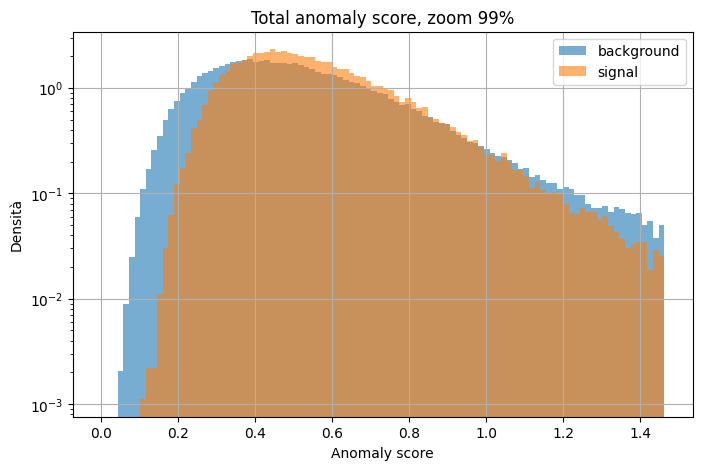

In [41]:
def plot_score_distribution_zoom(bg_scores, sig_scores, title, percentile=99):
    all_scores = np.concatenate([bg_scores, sig_scores])
    hi = np.percentile(all_scores, percentile)
    plt.figure(figsize=(8, 5))
    plt.hist(bg_scores, bins=100, range=(0, hi), density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=(0, hi), density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("Anomaly score")
    plt.ylabel("Densità")
    plt.title(f"{title}, zoom {percentile}%")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_score_distribution_zoom(scores_bg, scores_sig, "Total anomaly score")

## 22. ROC e AUC

ROC total score
AUC: 0.5522956236484523
AUC inverted: 0.4477043763515477
Best AUC: 0.5522956236484523


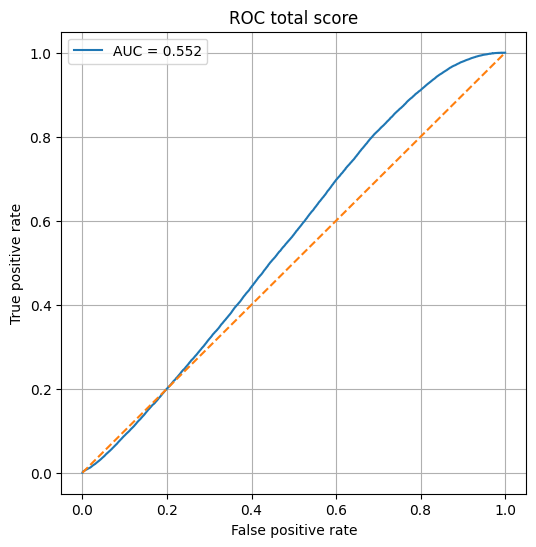

ROC jet score
AUC: 0.8968003127521543
AUC inverted: 0.10319968724784559
Best AUC: 0.8968003127521543


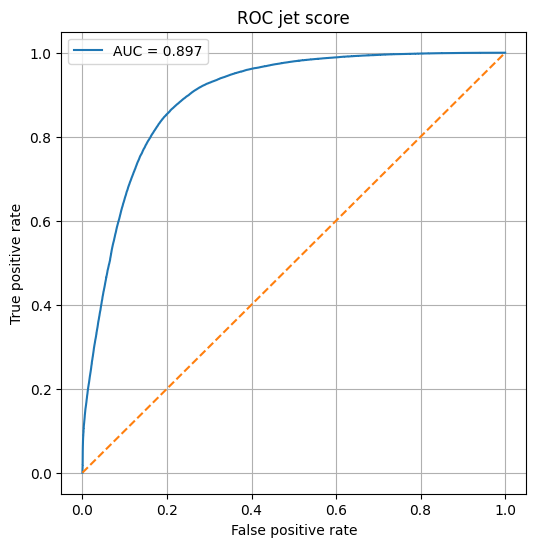

ROC track score
AUC: 0.4686259163089436
AUC inverted: 0.5313740836910564
Best AUC: 0.5313740836910564


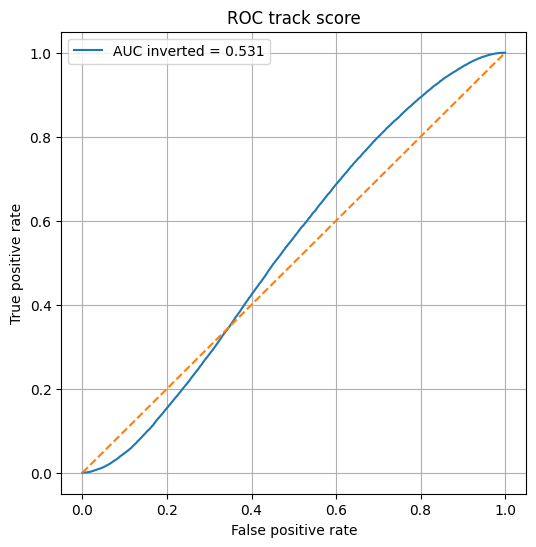

In [42]:
def compute_auc_and_plot(bg_scores, sig_scores, title):
    y_true = np.concatenate([np.zeros_like(bg_scores), np.ones_like(sig_scores)])
    y_score = np.concatenate([bg_scores, sig_scores])
    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)
    print(title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)
    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"
    fpr, tpr, thresholds = roc_curve(y_true, plot_score)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    return auc, auc_inv, best_auc

auc_total, auc_total_inv, best_auc_total = compute_auc_and_plot(scores_bg, scores_sig, "ROC total score")
auc_jets, auc_jets_inv, best_auc_jets = compute_auc_and_plot(scores_bg_jets, scores_sig_jets, "ROC jet score")
auc_tracks, auc_tracks_inv, best_auc_tracks = compute_auc_and_plot(scores_bg_tracks, scores_sig_tracks, "ROC track score")

## 23. Baseline supervisionata veloce su feature aggregate

In [ ]:
def aggregate_track_features(X_tracks, mask):
    features = []
    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)
    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)
        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)
        features.extend([mean, std, median, q90, maxv])
    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)

A_bg_tracks = aggregate_track_features(X_tracks_bg, mask_bg)
A_sig_tracks = aggregate_track_features(X_tracks_sig, mask_sig)
A_bg = np.concatenate([X_jets_bg, A_bg_tracks], axis=1)
A_sig = np.concatenate([X_jets_sig, A_sig_tracks], axis=1)
print("Aggregate bg:", A_bg.shape)
print("Aggregate sig:", A_sig.shape)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

X_clf = np.concatenate([A_bg, A_sig], axis=0)
y_clf = np.concatenate([np.zeros(len(A_bg), dtype=np.int64), np.ones(len(A_sig), dtype=np.int64)])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]
auc_clf = roc_auc_score(y_te, proba)
print("Aggregate supervised baseline AUC:", auc_clf)

## 24. Salvataggio modello e score

In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "n_jet_features": n_jet_features,
        "n_tracks": n_tracks,
        "n_track_features": n_track_features,
        "latent_dim": latent_dim,
        "jet_weight": jet_weight,
        "track_weight": track_weight,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_auc_total": best_auc_total,
        "best_auc_jets": best_auc_jets,
        "best_auc_tracks": best_auc_tracks,
    },
    OUTPUT_DIR / "jet_track_autoencoder.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "jet_track_autoencoder_scores.npz",
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    scores_bg_jets=scores_bg_jets,
    scores_sig_jets=scores_sig_jets,
    scores_bg_tracks=scores_bg_tracks,
    scores_sig_tracks=scores_sig_tracks,
    auc_total=np.array(auc_total, dtype=np.float32),
    auc_total_inv=np.array(auc_total_inv, dtype=np.float32),
    best_auc_total=np.array(best_auc_total, dtype=np.float32),
    auc_jets=np.array(auc_jets, dtype=np.float32),
    auc_tracks=np.array(auc_tracks, dtype=np.float32),
    auc_clf=np.array(auc_clf, dtype=np.float32),
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
)

print("Salvato modello:", OUTPUT_DIR / "jet_track_autoencoder.pt")
print("Salvati score:", OUTPUT_DIR / "jet_track_autoencoder_scores.npz")

## Note finali

Questo notebook è ancora una baseline semplice. Se l'AUC resta vicina a 0.5, i motivi probabili sono:

1. l'autoencoder flatten non è adatto a dati di tracce, perché le tracce sono più simili a un set che a un vettore ordinato;
2. la loss di ricostruzione non è lo score migliore;
3. bisogna usare modelli più adatti: per-track encoder con pooling, Transformer o GNN;
4. bisogna testare feature aggiuntive, incluse eventualmente le significance e le uncertainty-based feature.